# 🎓 SmartFee : An Intelligent Student Fee Recommendation System

## 📌 Project Overview

Educational institutions often follow a fixed fee structure or provide fee concessions using predefined rules. However, these approaches may not accurately reflect the financial condition of every student's family.

This project aims to develop a Machine Learning-based classification system that predicts whether a student should **pay the full fee** or **receive a fee concession** based on financial, family, and academic information.

The proposed system acts as a **decision support tool** to help educational institutions make transparent and data-driven fee assistance decisions.


# 🎯 Problem Statement

Many deserving students are unable to receive financial assistance because traditional fee concession systems often rely on limited criteria.

This project addresses this challenge by building an AI model that considers multiple socio-economic and academic factors before recommending whether a student should pay the full tuition fee.

The objective is to improve fairness, consistency, and transparency in fee concession decisions.


# 🎯 Objective

The primary objective of this project is to develop a Binary Classification Model that predicts whether a student should:

- ✅ Pay the Full Fee (Yes)
- ❌ Receive a Fee Concession (No)

using financial, demographic, and academic information.

The project also aims to compare multiple machine learning algorithms and identify the best-performing model.

# 📂 Dataset Overview

- Total Records : 10,000
- Total Features : 16
- Problem Type : Binary Classification

### Target Variable

**Pay_Full_Fee**

Possible Values:

- Yes
- No

The dataset contains both numerical and categorical features that represent the financial condition of a student's family and selected academic information.

# 📊 Dataset Features

| Feature | Description |
|---------|-------------|
| Student_ID | Unique identifier |
| Monthly_Income | Family's monthly income |
| Household_Size | Total family members |
| Number_of_Earning_Members | Number of earning members |
| Number_of_School_Going_Children | Children currently studying |
| Savings | Estimated monthly savings |
| Medical_Expenses | Monthly medical expenditure |
| Attendance | Student attendance percentage |
| Academic_Performance | Student academic score |
| Teacher_Evaluation | Teacher rating (1–5) |
| Income_Stability | Stable or Fluctuating income |
| House_Type | Owned or Rented |
| Location | Rural, Semi-Urban, Urban |
| Parent_Education | Parent's education level |
| Debt_Status | Existing debt status |
| Pay_Full_Fee | Target variable |


# 📌 Feature Importance

The dataset has been designed so that different features influence the final decision differently.

### Positive Influence

The following features increase the probability that a student will pay the full fee:

- Monthly Income
- Savings
- Number of Earning Members
- Stable Income
- Owned House
- Higher Parent Education

### Negative Influence

The following features increase the probability of receiving a fee concession:

- Household Size
- Medical Expenses
- Debt Status
- Number of School Going Children
- Lower Income


# 📋 Project Workflow

This notebook demonstrates the complete Machine Learning pipeline for predicting whether a student should **pay the full tuition fee** or **receive a fee concession** based on their family's financial condition and selected academic attributes.

The following steps will be performed throughout this project:

### 📌 1. Data Loading
- Import the dataset into Python using **Pandas**.
- Display the first few records and understand the dataset structure.

### 📌 2. Exploratory Data Analysis (EDA)
- Analyze the distribution of numerical and categorical features.
- Visualize class distribution of the target variable.
- Identify patterns, trends, and potential relationships between features.

### 📌 3. Data Preprocessing
- Check for missing values and handle them using appropriate imputation techniques.
- Detect duplicate records and remove them if necessary.
- Encode categorical variables into numerical format.
- Verify data types and prepare the dataset for machine learning.

### 📌 4. Feature Engineering
- Analyze feature importance and correlations.
- Select the most relevant features for model training.
- Prepare the final feature matrix (`X`) and target variable (`y`).

### 📌 5. Data Splitting
- Split the dataset into **training** and **testing** sets to evaluate model performance on unseen data.

### 📌 6. Model Training
The following classification algorithms will be trained and compared:

- Logistic Regression
- KNN
- naive bayes
- Random Forest Classifier


### 📌 7. Model Evaluation
Evaluate each model using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

### 📌 8. Model Comparison
Compare the performance of all models and identify the best-performing algorithm based on the evaluation metrics.

### 📌 9. Conclusion
Summarize the findings, discuss the strengths and limitations of the selected model, and provide recommendations for future improvements.

> **Goal:** Build a reliable AI-based decision support system that helps educational institutions make fair and transparent fee concession decisions using data-driven insights.

1. Prioritizing Recall (Focus on Equity & Assistance)
False Negative (FN): Predicting a student doesn't pay full fee (gets a concession) when they actually should pay full fee.

Impact: The institution loses a bit of tuition revenue, but deserving/in-need students get help.

False Positive (FP): Predicting a student pays full fee when they actually needed a concession.

Impact: High Risk. A financially struggling student is forced to pay full tuition and may drop out due to financial burden.

Why Recall Matters Most: If your goal is to ensure no needy student is mistakenly denied a concession, you want to minimize False Positives. In classification terms, maximizing Recall for the concession group (or minimizing False Positives) ensures deserving students are caught by the safety net.

2. Balancing with F1-Score (Focus on Financial Sustainability)
If you only maximize Recall, the model might grant concessions to almost everyone, hurting the institution's operational budget.

F1-Score gives you the harmonic mean of Precision and Recall, keeping a clean balance between not denying needy students (Recall) and not giving away too many unnecessary concessions (Precision).

In [1]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score,precision_score,recall_score,f1_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
# loading the data 
df = pd.read_csv("student_data.csv")

In [3]:
df.head()
df.info()
df.isna().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       10000 non-null  str    
 1   Monthly_Income                   9950 non-null   float64
 2   Household_Size                   9950 non-null   float64
 3   Number_of_Earning_Members        9950 non-null   float64
 4   Number_of_School_Going_Children  9950 non-null   float64
 5   Savings                          9950 non-null   float64
 6   Medical_Expenses                 9950 non-null   float64
 7   Attendance                       9950 non-null   float64
 8   Academic_Performance             9950 non-null   float64
 9   Teacher_Evaluation               9950 non-null   float64
 10  Income_Stability                 9950 non-null   str    
 11  House_Type                       9950 non-null   str    
 12  Location                      

,Monthly_Income,Household_Size,Number_of_Earning_Members,Number_of_School_Going_Children,Savings,Medical_Expenses,Attendance,Academic_Performance,Teacher_Evaluation
count,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000,9950.000000
mean,22629.788844,5.040201,2.329548,2.308040,2195.312563,2808.424824,87.943819,85.796281,4.264121
std,16581.850898,1.558131,1.023221,1.023046,2764.940483,1324.531749,5.879341,8.617199,0.660008
min,5000.000000,2.000000,1.000000,1.000000,0.000000,0.000000,65.000000,53.000000,2.000000
25%,11208.250000,4.000000,2.000000,1.000000,0.000000,1891.000000,84.000000,80.000000,4.000000
50%,17846.500000,5.000000,2.000000,2.000000,1169.500000,2810.500000,88.000000,86.000000,4.000000
75%,28365.500000,6.000000,3.000000,3.000000,3595.750000,3716.000000,92.000000,92.000000,5.000000
max,90000.000000,8.000000,4.000000,4.000000,16258.000000,8902.000000,100.000000,100.000000,5.000000


# Handling the Missing Values 

In [4]:
# spliting the columns on the basis of categorical and numerical columns 
categorical_col = df.select_dtypes(include = ["str"]).columns
num_col = df.select_dtypes(include = ["float64"]).columns

In [5]:
categorical_col

Index(['Student_ID', 'Income_Stability', 'House_Type', 'Location',
       'Parent_Education', 'Debt_Status', 'Pay_Full_Fee'],
      dtype='str')

In [6]:
num_col

Index(['Monthly_Income', 'Household_Size', 'Number_of_Earning_Members',
       'Number_of_School_Going_Children', 'Savings', 'Medical_Expenses',
       'Attendance', 'Academic_Performance', 'Teacher_Evaluation'],
      dtype='str')

In [7]:
# Using the Imputer to fill null values(for numerical columns)
num_imp = SimpleImputer(strategy="mean")
df[num_col] = num_imp.fit_transform(df[num_col])

In [8]:
# Using the Imputer to fill null values(for categorical columns)
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_col] = cat_imp.fit_transform(df[categorical_col])

In [9]:
# checking for null value 
df.isna().sum()

Student_ID                         0
Monthly_Income                     0
Household_Size                     0
Number_of_Earning_Members          0
Number_of_School_Going_Children    0
Savings                            0
Medical_Expenses                   0
Attendance                         0
Academic_Performance               0
Teacher_Evaluation                 0
Income_Stability                   0
House_Type                         0
Location                           0
Parent_Education                   0
Debt_Status                        0
Pay_Full_Fee                       0
dtype: int64

In [10]:
df.head()

,Student_ID,Monthly_Income,Household_Size,Number_of_Earning_Members,Number_of_School_Going_Children,Savings,Medical_Expenses,Attendance,Academic_Performance,Teacher_Evaluation,Income_Stability,House_Type,Location,Parent_Education,Debt_Status,Pay_Full_Fee
0,S00001,22279.0,6.0,1.0,4.0,2310.0,2243.0,90.0,92.0,5.0,Stable,Rented,Semi-Urban,Graduate,No,No
1,S00002,8691.0,4.0,4.0,3.0,0.0,1688.0,79.0,83.0,5.0,Fluctuating,Rented,Semi-Urban,Graduate,No,No
2,S00003,30437.0,7.0,3.0,4.0,4644.0,1327.0,85.0,87.0,4.0,Stable,Rented,Rural,Primary,No,Yes
3,S00004,34770.0,4.0,1.0,1.0,4324.0,1581.0,85.0,97.0,5.0,Stable,Owned,Urban,Primary,No,Yes
4,S00005,5000.0,4.0,3.0,1.0,0.0,4045.0,78.0,68.0,4.0,Fluctuating,Owned,Rural,Primary,Yes,No


# EDA - Exploratory data analysis

Text(0.5, 1.0, 'Fee will reduced or not ')

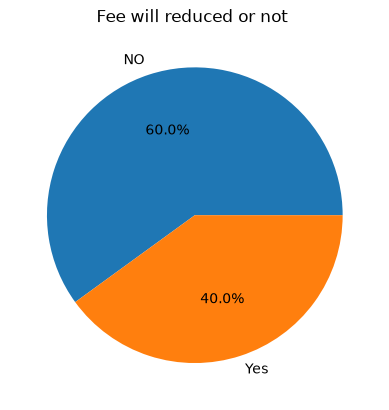

In [11]:
# Checking how balanced our classes(output(0-1)) are ?
class_count = df["Pay_Full_Fee"].value_counts()
plt.pie(class_count,labels=["NO","Yes"], autopct ="%1.1f%%")
plt.title("Fee will reduced or not ")

[Text(0, 0, '5204'), Text(0, 0, '4796')]

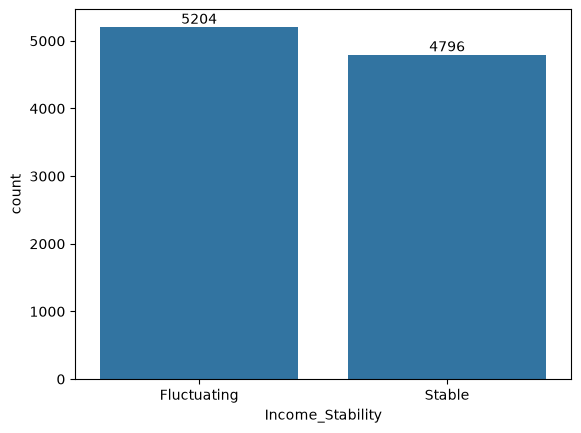

In [12]:
# analyze categories
stabe_count = df["Income_Stability"].value_counts()
ax = sns.barplot(stabe_count)
ax.bar_label(ax.containers[0])



<Axes: xlabel='Monthly_Income', ylabel='Count'>

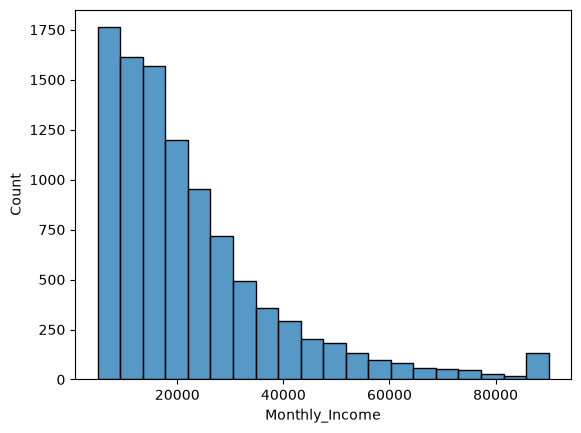

In [13]:
# analyze income
sns.histplot(
    data = df,
    x="Monthly_Income",
    bins=20
)

<Axes: xlabel='Savings', ylabel='Count'>

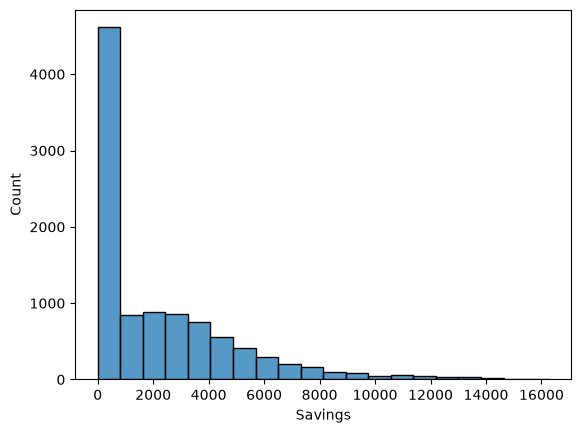

In [14]:
sns.histplot(
    data = df,
    x="Savings",
    bins = 20
)

<Axes: xlabel='Pay_Full_Fee', ylabel='Monthly_Income'>

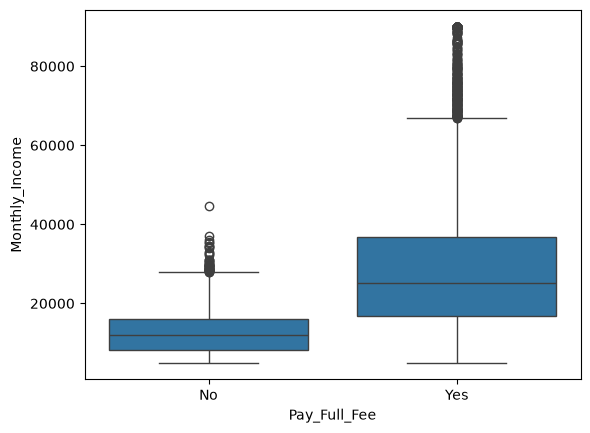

In [15]:
# outliers - box plots 

sns.boxplot(
    data=df,
    x = "Pay_Full_Fee",
    y = "Monthly_Income"
)

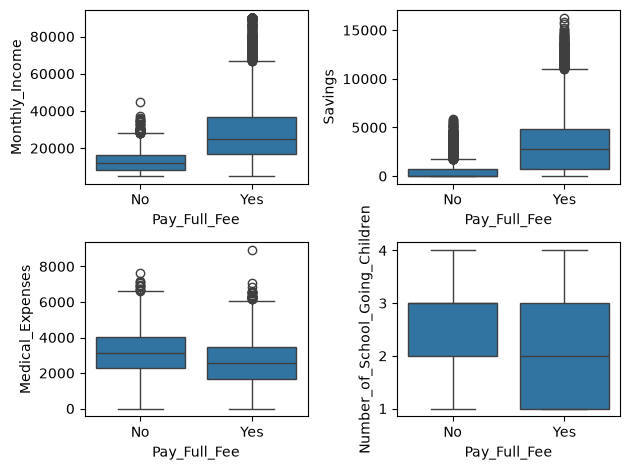

In [16]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0],data=df,x = "Pay_Full_Fee",y = "Monthly_Income")
sns.boxplot(ax = axes[0,1],data=df,x = "Pay_Full_Fee",y = "Savings")
sns.boxplot(ax = axes[1,0],data=df,x = "Pay_Full_Fee",y = "Medical_Expenses")
sns.boxplot(ax = axes[1,1],data=df,x = "Pay_Full_Fee",y = "Number_of_School_Going_Children")
plt.tight_layout()

<Axes: xlabel='Monthly_Income', ylabel='Count'>

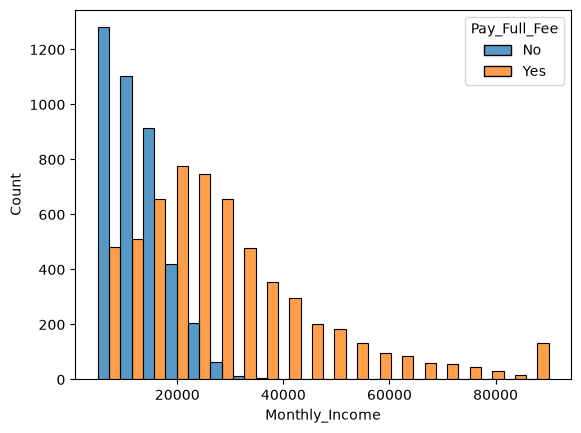

In [17]:
# Montly income with the pay_fee

sns.histplot(
    data = df,
    x = "Monthly_Income",
    hue="Pay_Full_Fee",
    bins = 20,
    multiple="dodge"
)

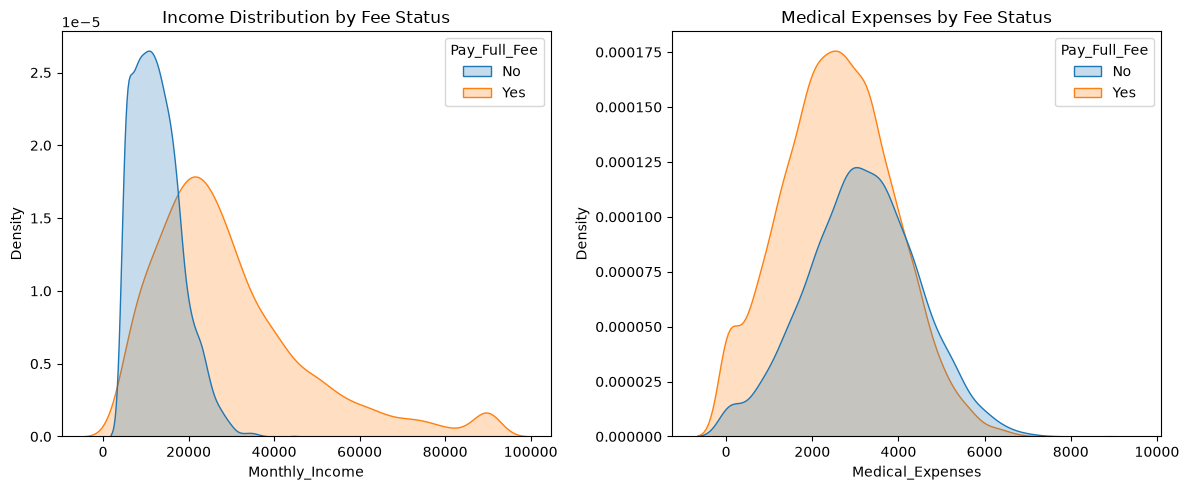

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data=df, x='Monthly_Income', hue='Pay_Full_Fee', fill=True, ax=axes[0])
axes[0].set_title('Income Distribution by Fee Status')

sns.kdeplot(data=df, x='Medical_Expenses', hue='Pay_Full_Fee', fill=True, ax=axes[1])
axes[1].set_title('Medical Expenses by Fee Status')
plt.tight_layout()
plt.show()

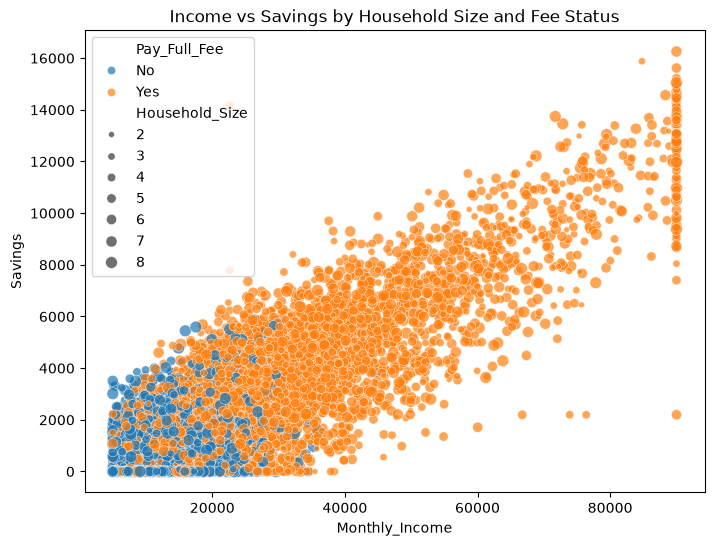

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, 
    x='Monthly_Income', 
    y='Savings', 
    hue='Pay_Full_Fee', 
    size='Household_Size', 
    alpha=0.7
)
plt.title('Income vs Savings by Household Size and Fee Status')
plt.show()

In [20]:
# removed the Student_ID column 
df = df.drop("Student_ID", axis = 1)
df.head(2)

,Monthly_Income,Household_Size,Number_of_Earning_Members,Number_of_School_Going_Children,Savings,Medical_Expenses,Attendance,Academic_Performance,Teacher_Evaluation,Income_Stability,House_Type,Location,Parent_Education,Debt_Status,Pay_Full_Fee
0,22279.0,6.0,1.0,4.0,2310.0,2243.0,90.0,92.0,5.0,Stable,Rented,Semi-Urban,Graduate,No,No
1,8691.0,4.0,4.0,3.0,0.0,1688.0,79.0,83.0,5.0,Fluctuating,Rented,Semi-Urban,Graduate,No,No


# Encoding 

In [21]:
# Encoding of categorical columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Monthly_Income                   10000 non-null  float64
 1   Household_Size                   10000 non-null  float64
 2   Number_of_Earning_Members        10000 non-null  float64
 3   Number_of_School_Going_Children  10000 non-null  float64
 4   Savings                          10000 non-null  float64
 5   Medical_Expenses                 10000 non-null  float64
 6   Attendance                       10000 non-null  float64
 7   Academic_Performance             10000 non-null  float64
 8   Teacher_Evaluation               10000 non-null  float64
 9   Income_Stability                 10000 non-null  str    
 10  House_Type                       10000 non-null  str    
 11  Location                         10000 non-null  str    
 12  Parent_Education              

In [22]:
# label Encoding 
le  = LabelEncoder()
df["Pay_Full_Fee"] = le.fit_transform(df["Pay_Full_Fee"])
df["Income_Stability"] = le.fit_transform(df["Income_Stability"])
df["House_Type"] = le.fit_transform(df["House_Type"])
df["Debt_Status"] = le.fit_transform(df["Debt_Status"])
df["Parent_Education"] = le.fit_transform(df["Parent_Education"])

In [23]:
# One Hot Encoding 
cols = ["Location"]
ohe = OneHotEncoder(drop = "first",sparse_output=False) # assing parms
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded,columns = ohe.get_feature_names_out(cols),index =  df.index)

df = pd.concat([df.drop(columns = cols),encoded_df],axis=1)

# Correlation HeatMap

In [24]:
num_col = df.select_dtypes(include="number")
cor_mat = num_col.corr()
num_col.corr()["Pay_Full_Fee"].sort_values(ascending =  False)

Pay_Full_Fee                       1.000000
Monthly_Income                     0.489990
Savings                            0.486027
Income_Stability                   0.295164
Number_of_Earning_Members          0.121858
Location_Semi-Urban                0.005303
Attendance                        -0.015493
Location_Urban                    -0.015711
Parent_Education                  -0.019470
Teacher_Evaluation                -0.022216
Academic_Performance              -0.022338
House_Type                        -0.198135
Number_of_School_Going_Children   -0.203976
Medical_Expenses                  -0.207549
Household_Size                    -0.213440
Debt_Status                       -0.372345
Name: Pay_Full_Fee, dtype: float64

<Axes: >

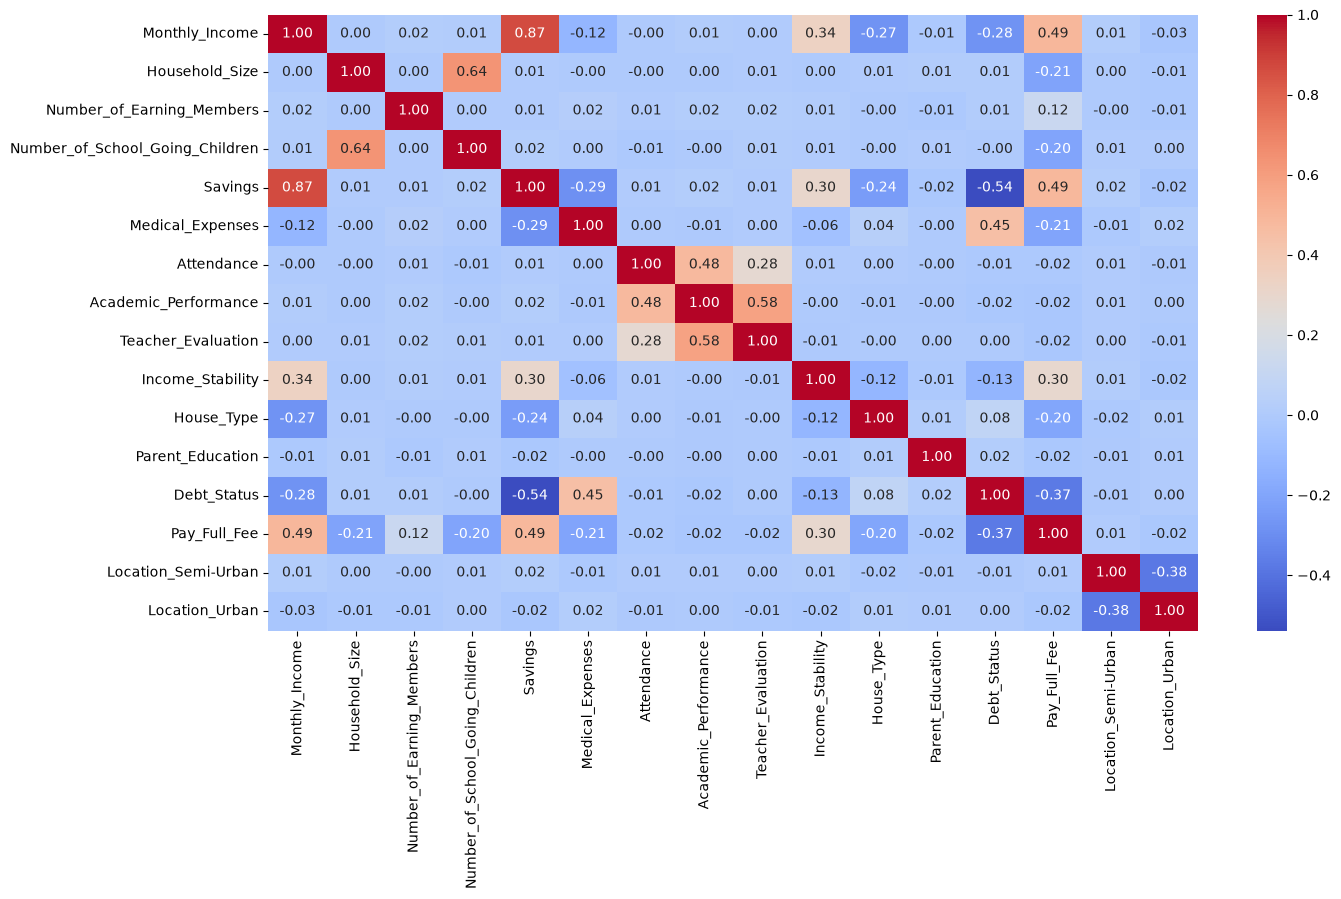

In [25]:
# heat map 
plt.figure(figsize=(15,8))
sns.heatmap(
    cor_mat,
    annot = True,
    fmt = ".2f",
    cmap ="coolwarm"
)

In [26]:
# Spliting the data set in x and y
x = df.drop("Pay_Full_Fee", axis=1)
y = df["Pay_Full_Fee"]

In [27]:
x.head()

,Monthly_Income,Household_Size,Number_of_Earning_Members,Number_of_School_Going_Children,Savings,Medical_Expenses,Attendance,Academic_Performance,Teacher_Evaluation,Income_Stability,House_Type,Parent_Education,Debt_Status,Location_Semi-Urban,Location_Urban
0,22279.0,6.0,1.0,4.0,2310.0,2243.0,90.0,92.0,5.0,1,1,0,0,1.0,0.0
1,8691.0,4.0,4.0,3.0,0.0,1688.0,79.0,83.0,5.0,0,1,0,0,1.0,0.0
2,30437.0,7.0,3.0,4.0,4644.0,1327.0,85.0,87.0,4.0,1,1,1,0,0.0,0.0
3,34770.0,4.0,1.0,1.0,4324.0,1581.0,85.0,97.0,5.0,1,0,1,0,0.0,1.0
4,5000.0,4.0,3.0,1.0,0.0,4045.0,78.0,68.0,4.0,0,0,1,1,0.0,0.0


In [28]:
# Train_test_split
x_train,x_test,y_train,y_test =  train_test_split(x,y, test_size=0.2, random_state=42)

In [29]:
x_train.head(2)

,Monthly_Income,Household_Size,Number_of_Earning_Members,Number_of_School_Going_Children,Savings,Medical_Expenses,Attendance,Academic_Performance,Teacher_Evaluation,Income_Stability,House_Type,Parent_Education,Debt_Status,Location_Semi-Urban,Location_Urban
9254,9419.0,3.0,2.0,1.0,0.0,5296.0,98.0,88.0,5.0,0,1,1,1,0.0,1.0
1561,19852.0,6.0,4.0,3.0,3655.0,0.0,97.0,89.0,5.0,1,0,1,0,0.0,1.0


# Choosing the best suitable model 

### Scaling 

In [30]:
scaler = StandardScaler()
x_train_scaled =scaler.fit_transform(x_train)
x_test_scaled =scaler.transform(x_test)

In [31]:
x_test_scaled

array([[ 0.81435572, -0.02135378, -1.30136016, ..., -1.01055571,
         1.75783377, -0.66167554],
       [-0.68031969,  1.26478511, -0.32373648, ...,  0.98955455,
        -0.56888201,  1.51131474],
       [-0.3104464 , -1.30749267, -1.30136016, ...,  0.98955455,
        -0.56888201,  1.51131474],
       ...,
       [-1.03435322,  1.26478511,  0.65388719, ...,  0.98955455,
        -0.56888201, -0.66167554],
       [ 1.17514356,  1.90785455, -1.30136016, ..., -1.01055571,
         1.75783377, -0.66167554],
       [-0.1212659 , -1.30749267,  0.65388719, ...,  0.98955455,
        -0.56888201,  1.51131474]], shape=(2000, 15))

In [32]:
# Starting With Logistic Regression model
log_model  =  LogisticRegression()
log_model.fit(x_train_scaled,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [33]:
y_preds = log_model.predict(x_test_scaled)
print("Logistic Regression")
print("precision : ", precision_score(y_test,y_preds))
print("recall : ", recall_score(y_test,y_preds))
print("accuracy : ", accuracy_score(y_test,y_preds))
print("f1 : ", f1_score(y_test,y_preds))
print("confussion Mat", confusion_matrix(y_test,y_preds))
# good recall and f1 

Logistic Regression
precision :  0.865684575389948
recall :  0.8516624040920716
accuracy :  0.8355
f1 :  0.8586162440911044
confussion Mat [[672 155]
 [174 999]]


In [34]:
# Testing on knn model know
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [35]:
y_preds = knn.predict(x_test_scaled)

print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ", recall_score(y_test,y_preds)*100,"%")
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")
print("confussion Mat", confusion_matrix(y_test,y_preds))

precision :  81.05726872246696 %
recall :  78.43137254901961 %
accuracy :  76.6 %
f1 :  79.72270363951473 %
confussion Mat [[612 215]
 [253 920]]


In [36]:
# know checking for the naive_bayes
gnv = GaussianNB()
gnv.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[3173.,4827.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.4,0.6]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.2799
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['Monthly_Income','Household_Size','Number_of_Earning_Members',..., 'Debt_Status','Location_Semi-Urban','Location_Urban']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 15)","[[12712.38, 5.44, 2.18,..., 0.73, 0.24, 0.31], [29445.6 , 4.76, 2.43,..., 0.36, 0.25, 0.3 ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 15)","[[3.08e+07,2.52e+00,1.26e+00,...,4.77e-01,4.62e-01,4.95e-01], [3.33e+08,2.63e+00,1.35e+00,...,5.10e-01,4.67e-01,4.89e-01]]"


In [37]:
y_preds = gnv.predict(x_test)
print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ", recall_score(y_test,y_preds)*100,"%")
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")
print("confussion Mat", confusion_matrix(y_test,y_preds))

precision :  92.0814479638009 %
recall :  69.39471440750214 %
accuracy :  78.55 %
f1 :  79.14438502673798 %
confussion Mat [[757  70]
 [359 814]]


In [38]:
# DecisionTreeClassifier
dtc = DecisionTreeClassifier(max_depth=3)
dtc.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [39]:
y_preds = dtc.predict(x_test)
print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ", recall_score(y_test,y_preds)*100,"%")
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")
print("confussion Mat", confusion_matrix(y_test,y_preds))

precision :  86.60714285714286 %
recall :  74.42455242966753 %
accuracy :  78.25 %
f1 :  80.05502063273727 %
confussion Mat [[692 135]
 [300 873]]


In [40]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 6, 8, 10, 12, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

dtc = DecisionTreeClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=dtc,
    param_distributions=param_dist,
    n_iter=25,             
    cv=3,                  
    scoring='recall',    
    n_jobs=-1,           
    random_state=42
)

random_search.fit(x_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [4, 6, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also

In [41]:
print("Best Hyperparameters found:")
print(random_search.best_params_)
print(f"Best CV Recall Score: {random_search.best_score_ * 100:.2f}%")

Best Hyperparameters found:
{'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 6, 'criterion': 'entropy'}
Best CV Recall Score: 79.97%


In [42]:
# model after hypertuning 
dtc = DecisionTreeClassifier(
    min_samples_split=2,
    min_samples_leaf=8,
    max_features='log2',
    max_depth=6,
    criterion='entropy'
)

In [43]:
dtc.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'log2'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamp

In [44]:
y_preds = dtc.predict(x_test)
y_pred_train = dtc.predict(x_train)
print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ", recall_score(y_test,y_preds)*100,"%")
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
print("accuracy of train : ", accuracy_score(y_train,y_pred_train)*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")
print("confussion Mat", confusion_matrix(y_test,y_preds))
# not a overfit 

precision :  88.44114528101802 %
recall :  71.0997442455243 %
accuracy :  77.60000000000001 %
accuracy of train :  78.57499999999999 %
f1 :  78.82797731568998 %
confussion Mat [[718 109]
 [339 834]]


In [45]:
# Random Forest 
rf = RandomForestClassifier(
    random_state=42,
     n_estimators= 125, # 125
    oob_score=True,
)
rf.fit(x_train,y_train)

# till know best parms

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",125
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the followi

In [46]:
y_preds = rf.predict(x_test)
print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ", recall_score(y_test,y_preds)*100,"%")
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
# print("accuracy of train : ", accuracy_score(y_train,y_pred_train)*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")

precision :  89.11627906976744 %
recall :  81.67092924126173 %
accuracy :  83.39999999999999 %
f1 :  85.23131672597864 %


In [47]:

rf_param_dist = {
    'n_estimators': [50, 100, 150, 125],
    'criterion': ['gini', 'entropy'],
    'max_depth': [6, 8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}


rf = RandomForestClassifier(random_state=42)


random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=20,               
    cv=3,                    
    scoring='recall',       
    n_jobs=-1,               
    random_state=42
)


random_search_rf.fit(x_train, y_train)




,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [6, 8, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Al

In [48]:
print("--- Random Forest Tuning Results ---")
print("Best Hyperparameters:", random_search_rf.best_params_)
print(f"Best CV Recall Score: {random_search_rf.best_score_ * 100:.2f}%")

--- Random Forest Tuning Results ---
Best Hyperparameters: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'gini'}
Best CV Recall Score: 81.62%


In [338]:
rf = RandomForestClassifier(
    random_state=42,
     n_estimators= 125, 
    oob_score=True,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features="log2",
    max_depth=3,
    criterion="gini"
)
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",125
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following

In [339]:
y_preds = rf.predict(x_test)
print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ", recall_score(y_test,y_preds)*100,"%")
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
# print("accuracy of train : ", accuracy_score(y_train,y_pred_train)*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")

precision :  86.29876308277831 %
recall :  77.3231031543052 %
accuracy :  79.5 %
f1 :  81.56474820143885 %


In [345]:
# GradientBoosting
gbc = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=221, #144
    max_depth=3,
    random_state=11
)
gbc.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",221
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",11
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [346]:
y_preds = gbc.predict(x_test)
print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ", recall_score(y_test,y_preds)*100,"%")
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")

precision :  88.04347826086956 %
recall :  82.86445012787725 %
accuracy :  83.35000000000001 %
f1 :  85.37549407114624 %


In [344]:
# XGBOOT
import xgboost as xgb

In [347]:
xgb_clf1 =  xgb.XGBClassifier(
    n_estimators = 210, # 210
    max_depth = 3,
    learning_rate = 0.1,
    eval_metric="logloss",
    random_state=42
)

In [349]:
xgb_clf1.fit(x_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [350]:
y_probs = xgb_clf1.predict_proba(x_test)[:, 1]

custom_threshold = 0.40
y_preds_custom = (y_probs >= custom_threshold).astype(int)
print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ",recall_score(y_test, y_preds_custom) * 100)
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")

precision :  88.04347826086956 %
recall :  86.53026427962489
accuracy :  83.35000000000001 %
f1 :  85.37549407114624 %


In [171]:
# hyper tuning 
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],     
    'min_child_weight': [1, 3, 5],          
    'scale_pos_weight': [1, 1.2, 1.5]
}
xgb_model = xgb.XGBClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1', # or 'recall'
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

# Best tuned model
best_xgb = random_search.best_estimator_
y_preds_tuned = best_xgb.predict(x_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [172]:
print("Best Parameters Found:")
print(random_search.best_params_)

print("\nBest CV Score (F1/Recall):", random_search.best_score_)

Best Parameters Found:
{'subsample': 0.7, 'scale_pos_weight': 1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best CV Score (F1/Recall): 0.8546282949674129


In [272]:
xgb_clf =  xgb.XGBClassifier(
    n_estimators = 210,
    subsample=0.7, 
    scale_pos_weight = 1,
    max_depth = 3,
    learning_rate = 0.1,
    min_child_weight=1, # 1
    eval_metric="logloss",
    colsample_bytree=0.2, 
    random_state=15,

)

# best till know 

In [273]:
xgb_clf.fit(x_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.2
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [351]:
y_preds = xgb_clf.predict(x_test)
y_train_pred = xgb_clf.predict(x_train)
y_probs = xgb_clf.predict_proba(x_test)[:, 1]

custom_threshold = 0.40
y_preds_custom = (y_probs >= custom_threshold).astype(int)
print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ",recall_score(y_test, y_preds_custom) * 100)
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
print("accuracy on traing data: ", accuracy_score(y_train,y_train_pred )*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")

precision :  88.76712328767124 %
recall :  87.04177323103154
accuracy :  83.8 %
accuracy on traing data:  84.96249999999999 %
f1 :  85.71428571428571 %


In [289]:
!pip install catboost

In [299]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='F1',
    random_seed=42,
    verbose=24
)

cat_model.fit(x_train, y_train, eval_set=(x_test, y_test))


0:	learn: 0.8222075	test: 0.8159565	best: 0.8159565 (0)	total: 6.26ms	remaining: 3.12s
24:	learn: 0.8500601	test: 0.8395172	best: 0.8395172 (24)	total: 166ms	remaining: 3.16s
48:	learn: 0.8595150	test: 0.8550920	best: 0.8550920 (48)	total: 300ms	remaining: 2.76s
72:	learn: 0.8647411	test: 0.8550920	best: 0.8556054 (68)	total: 429ms	remaining: 2.51s
96:	learn: 0.8683033	test: 0.8540734	best: 0.8570148 (82)	total: 560ms	remaining: 2.33s
120:	learn: 0.8726323	test: 0.8545861	best: 0.8570148 (82)	total: 688ms	remaining: 2.15s
144:	learn: 0.8752044	test: 0.8561183	best: 0.8570148 (82)	total: 817ms	remaining: 2s
168:	learn: 0.8767452	test: 0.8579088	best: 0.8590604 (157)	total: 946ms	remaining: 1.85s
192:	learn: 0.8807680	test: 0.8581624	best: 0.8590604 (157)	total: 1.08s	remaining: 1.72s
216:	learn: 0.8828848	test: 0.8563782	best: 0.8590604 (157)	total: 1.21s	remaining: 1.58s
240:	learn: 0.8859133	test: 0.8586714	best: 0.8590604 (157)	total: 1.34s	remaining: 1.44s
264:	learn: 0.8902413	test

CatBoostClassifier(depth=6, eval_metric='F1', iterations=500, learning_rate=0.05, random_seed=42, verbose=24)

In [300]:
# Make predictions
y_preds_cat = cat_model.predict(x_test)
y_probs_cat = cat_model.predict_proba(x_test)[:, 1]

print("CatBoost Performance Metrics:")
print("Precision : ", precision_score(y_test, y_preds_cat) * 100, "%")
print("Recall    : ", recall_score(y_test, y_preds_cat) * 100, "%")
print("Accuracy  : ", accuracy_score(y_test, y_preds_cat) * 100, "%")
print("F1-Score  : ", f1_score(y_test, y_preds_cat) * 100, "%")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_preds_cat))

CatBoost Performance Metrics:
Precision :  89.86046511627906 %
Recall    :  82.35294117647058 %
Accuracy  :  84.2 %
F1-Score  :  85.94306049822063 %

Confusion Matrix:
 [[718 109]
 [207 966]]


In [309]:
param_grid = {
    'n_estimators': [210, 260, 300],          
    'learning_rate': [0.05, 0.08, 0.1],       
    'max_depth': [3, 4],                      
    'subsample': [0.7, 0.8],                  
    'colsample_bytree': [0.2, 0.4, 0.6],      
    'min_child_weight': [1, 2],               
    'scale_pos_weight': [1.0, 1.1, 1.2],      
    'gamma': [0, 0.1]                         
}

In [310]:
xgb_base = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=15
)

In [311]:
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [313]:

grid_search.fit(x_train, y_train)


best_xgb = grid_search.best_estimator_

y_probs = best_xgb.predict_proba(x_test)[:, 1]
custom_threshold = 0.40
y_preds_custom = (y_probs >= custom_threshold).astype(int)

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


In [314]:
print(grid_search.best_params_)
print("precision : ", precision_score(y_test, y_preds_custom) * 100, "%")
print("recall    : ", recall_score(y_test, y_preds_custom) * 100, "%")
print("accuracy  : ", accuracy_score(y_test, y_preds_custom) * 100, "%")
print("f1        : ", f1_score(y_test, y_preds_custom) * 100, "%")

--- Best Parameters Found ---
{'colsample_bytree': 0.2, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 210, 'scale_pos_weight': 1.0, 'subsample': 0.8}

--- Model Metrics ---
precision :  84.82293423271501 %
recall    :  85.76300085251492 %
accuracy  :  82.65 %
f1        :  85.29037727850785 %


In [334]:
# trying adaBoost 
from sklearn.ensemble import AdaBoostClassifier
base_model = DecisionTreeClassifier(
    min_samples_split=2,
    min_samples_leaf=8,
    max_features='log2',
    max_depth=3,
    criterion='entropy'
)

# adaboost classifier
abc = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=221,
    random_state=11
)

In [335]:
# train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [336]:
abc.fit(x_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...amples_leaf=8)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",221
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",11
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...amples_leaf=8)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](221,)","[0.23,0.33,0.32,...,0.5 ,0.48,0.48]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](221,)","[1.19,0.73,0.77,...,0.01,0.09,0.08]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...ate=774252441), DecisionTreeC...ate=293375679), DecisionTreeC...tate=83645520), DecisionTreeC...ate=707468379), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](17,)","[0.2 ,0.08,0.03,...,0.01,0.18,0.13]"


In [337]:
y_preds= abc.predict(x_test)
print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ", recall_score(y_test,y_preds)*100,"%")
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")

precision :  87.14285714285714 %
recall :  83.20545609548167 %
accuracy :  82.95 %
f1 :  85.12865242040995 %


# The best model after testing is  `XGBOOST`

In [352]:
# Xgboost 
xgb_clf =  xgb.XGBClassifier(
    n_estimators = 210,
    subsample=0.7, 
    scale_pos_weight = 1,
    max_depth = 3,
    learning_rate = 0.1,
    min_child_weight=1, # 1
    eval_metric="logloss",
    colsample_bytree=0.2, 
    random_state=15,

)
xgb_clf.fit(x_train,y_train)

y_preds = xgb_clf.predict(x_test)
y_train_pred = xgb_clf.predict(x_train)
y_probs = xgb_clf.predict_proba(x_test)[:, 1]

custom_threshold = 0.40
y_preds_custom = (y_probs >= custom_threshold).astype(int)
print("precision : ", precision_score(y_test,y_preds)*100,"%")
print("recall : ",recall_score(y_test, y_preds_custom) * 100)
print("accuracy : ", accuracy_score(y_test,y_preds)*100,"%")
print("accuracy on traing data: ", accuracy_score(y_train,y_train_pred )*100,"%")
print("f1 : ", f1_score(y_test,y_preds)*100,"%")

precision :  88.76712328767124 %
recall :  87.04177323103154
accuracy :  83.8 %
accuracy on traing data:  84.96249999999999 %
f1 :  85.71428571428571 %


In [353]:
import joblib

#  Save the model
joblib.dump(xgb_clf, "xgboost_model.pkl")

#  Save OneHotEncoder (for Location)
joblib.dump(ohe, "ohe_encoder.pkl")

#  Save the exact training column list & order
joblib.dump(x_train.columns.tolist(), "model_columns.pkl")

print(
   "All deployment files saved successfully!"
)

All deployment files saved successfully!
